In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U tensorflow numpy matplotlib seaborn scikit-learn

import os
import shutil
import zipfile
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
zip_path = "/content/drive/MyDrive/Plant_leave_diseases_dataset(WA).zip"


In [4]:
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [5]:
import os

print(os.listdir("/content/dataset"))

['Plant_leave_diseases_dataset_without_augmentation']


In [6]:
data_dir = "/content/dataset/Plant_leave_diseases_dataset_without_augmentation"

In [7]:
classes = os.listdir(data_dir)
print("Total classes:", len(classes))
print(classes[:39])

Total classes: 39
['Tomato___Bacterial_spot', 'Peach___Bacterial_spot', 'Grape___Esca_(Black_Measles)', 'Tomato___Leaf_Mold', 'Pepper,_bell___healthy', 'Cherry___healthy', 'Corn___Northern_Leaf_Blight', 'Corn___Common_rust', 'Peach___healthy', 'Raspberry___healthy', 'Pepper,_bell___Bacterial_spot', 'Orange___Haunglongbing_(Citrus_greening)', 'Potato___Late_blight', 'Background_without_leaves', 'Grape___healthy', 'Apple___healthy', 'Tomato___Early_blight', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Late_blight', 'Grape___Black_rot', 'Blueberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Potato___healthy', 'Squash___Powdery_mildew', 'Apple___Black_rot', 'Soybean___healthy', 'Apple___Apple_scab', 'Potato___Early_blight', 'Corn___healthy', 'Strawberry___healthy', 'Apple___Cedar_apple_rust', 'Tomato___Tomato_mosaic_

In [8]:
import os
import shutil

source_dir = "/content/dataset/Plant_leave_diseases_dataset_without_augmentation"
target_dir = "/content/filtered_dataset"

os.makedirs(target_dir, exist_ok=True)

plants = ["Apple", "Tomato", "Potato", "Strawberry"]

for folder in os.listdir(source_dir):
    for plant in plants:
        if folder.startswith(plant):
            src = os.path.join(source_dir, folder)
            dst = os.path.join(target_dir, folder)

            shutil.copytree(src, dst, dirs_exist_ok=True)

print("Filtered dataset ready!")

Filtered dataset ready!


In [9]:
import os

print(os.listdir("/content/filtered_dataset"))

['Tomato___Bacterial_spot', 'Tomato___Leaf_Mold', 'Potato___Late_blight', 'Apple___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Strawberry___Leaf_scorch', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Potato___healthy', 'Apple___Black_rot', 'Apple___Apple_scab', 'Potato___Early_blight', 'Strawberry___healthy', 'Apple___Cedar_apple_rust', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy', 'Tomato___Target_Spot']


**LOADING DATA**

In [10]:
import tensorflow as tf

IMG_SIZE = (160, 160)
BATCH_SIZE = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Final classes:", class_names)

Found 55448 files belonging to 39 classes.
Using 44359 files for training.
Found 55448 files belonging to 39 classes.
Using 11089 files for validation.
Final classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_b

In [11]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(2)
val_ds = val_ds.prefetch(2)

**DATA AUGMENTATION**

In [12]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

VISUAL CHECK

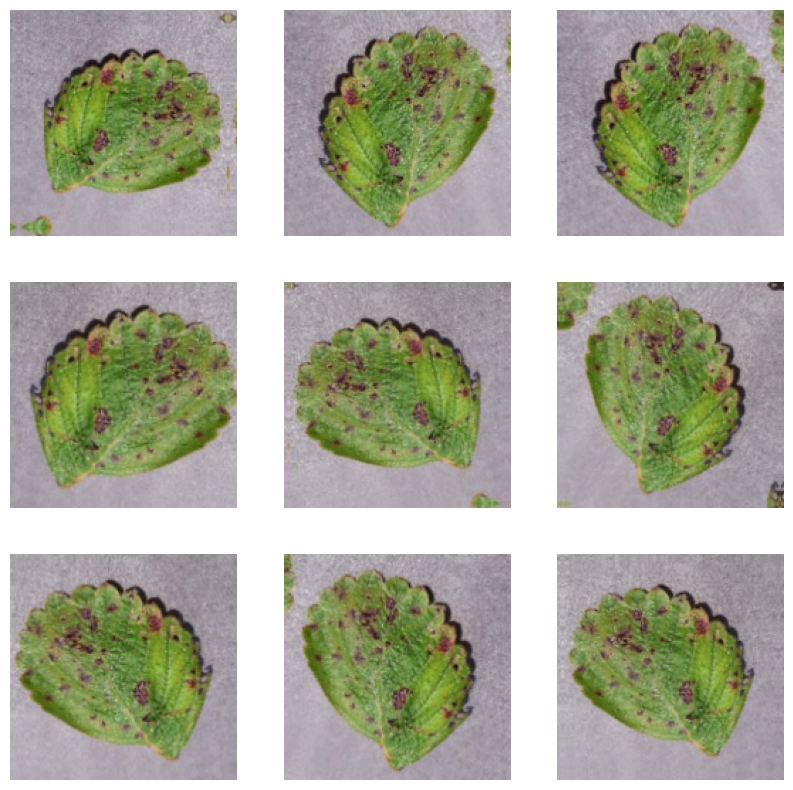

In [13]:
for images, _ in train_ds.take(1):
    plt.figure(figsize=(10,10))
    first_image = images[0]

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        augmented = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")

**MOBILE NET V2**

In [14]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model = tf.keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),

    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation="softmax")
])

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
SAVE_DIR = "/content/drive/MyDrive/plant_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

In [18]:
import re
import json

SAVE_DIR = "/content/drive/MyDrive/plant_checkpoints"
BEST_MODEL_PATH = "/content/drive/MyDrive/best_model.keras"
BEST_ACC_FILE = "/content/drive/MyDrive/best_acc.json"

def keep_last_n_models(folder, n=3):
    files = sorted(
        [f for f in os.listdir(folder) if f.endswith(".keras")],
        key=lambda x: os.path.getmtime(os.path.join(folder, x))
    )
    if len(files) > n:
        for f in files[:-n]:
            os.remove(os.path.join(folder, f))
            print(f" Deleted: {f}")

def get_latest_model(folder):
    files = [f for f in os.listdir(folder) if f.endswith(".keras")]
    if not files:
        return None
    files.sort(key=lambda x: os.path.getmtime(os.path.join(folder, x)))
    return os.path.join(folder, files[-1])

def get_last_epoch(folder):
    files = [f for f in os.listdir(folder) if f.endswith(".keras")]
    if not files:
        return 0
    files.sort(key=lambda x: os.path.getmtime(os.path.join(folder, x)))
    last_file = files[-1]
    match = re.search(r"epoch_(\d+)", last_file)
    return int(match.group(1)) if match else 0

def load_best_acc():
    if os.path.exists(BEST_ACC_FILE):
        return json.load(open(BEST_ACC_FILE))["best"]
    return 0

def save_best_acc(val):
    json.dump({"best": val}, open(BEST_ACC_FILE, "w"))

**TRAINING**

In [19]:
EPOCHS = 10
KEEP_LAST_N = 3

start_epoch = get_last_epoch(SAVE_DIR)
best_val_acc = load_best_acc()

latest_model = get_latest_model(SAVE_DIR)
if latest_model:
    print("Resuming from:", latest_model)
    model = tf.keras.models.load_model(latest_model)
else:
    print("Starting fresh training")

print("Start epoch:", start_epoch)
print("Best accuracy:", best_val_acc)

for epoch in range(start_epoch, EPOCHS):
    print("Training epoch", epoch + 1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=1,
        verbose=1
    )

    val_acc = history.history["val_accuracy"][0]

    path = os.path.join(SAVE_DIR, f"model_epoch_{epoch+1}.keras")
    model.save(path)

    print("Saved:", path)

    keep_last_n_models(SAVE_DIR, KEEP_LAST_N)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_best_acc(best_val_acc)
        model.save(BEST_MODEL_PATH)
        print("New best model:", val_acc)

print("Main training complete")

Resuming from: /content/drive/MyDrive/plant_checkpoints/model_epoch_10.keras
Start epoch: 10
Best accuracy: 0.9301109313964844
Main training complete


**FINE TUNING**


In [ ]:
FINE_EPOCHS = 10
KEEP_LAST_N = 3

print("Loading best/latest model for fine-tuning")

latest_model = get_latest_model(SAVE_DIR)
if latest_model:
    model = tf.keras.models.load_model(latest_model)
    print("Loaded:", latest_model)
else:
    print("No model found for fine-tuning")
    raise ValueError("Run training first")

# Unfreeze layers
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_start = get_last_epoch(SAVE_DIR)

for epoch in range(fine_start, fine_start + FINE_EPOCHS):
    print("Fine-tune epoch", epoch + 1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=1,
        verbose=1
    )

    val_acc = history.history["val_accuracy"][0]

    path = os.path.join(SAVE_DIR, f"fine_epoch_{epoch+1}.keras")
    model.save(path)

    print("Saved:", path)

    keep_last_n_models(SAVE_DIR, KEEP_LAST_N)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_best_acc(best_val_acc)
        model.save(BEST_MODEL_PATH)
        print("New best (fine-tune):", val_acc)

print("Fine-tuning complete")

Loading best/latest model for fine-tuning
Loaded: /content/drive/MyDrive/plant_checkpoints/model_epoch_10.keras
Fine-tune epoch 11
1013/2773 ━━━━━━━━━━━━━━━━━━━━ 45:17 2s/step - accuracy: 0.4861 - loss: 5.1488

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)
print("Validation Loss:", loss)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
base_model.trainable = True

# freeze early layers only
for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**CONFUSION MATRIX**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

# Disable training behavior (important)
model.trainable = False

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,              \
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
model.save("/content/drive/MyDrive/plant_final_model.keras")